# 03 — Segmentación de Mercados y ML complementario

Tres vistas de clustering + técnicas ML adicionales (PCA, IsolationForest, clasificador de preferencia de tipo de café), todas apropiadas al tamaño (n=53 países).

In [1]:
import sys; sys.path.insert(0, '../src')
import pandas as pd, matplotlib.pyplot as plt
from data_prep import build_long_dataset
from features import build_and_save
from clustering import (select_k, cluster_view, profile, label_consumption_clusters,
                        CONSUMPTION_FEATURES, PREFERENCE_FEATURES)
from ml_extra import pca_2d, detect_anomalies, classify_coffee_preference
import viz; viz.set_style()
long_df = build_long_dataset(); feats = build_and_save(long_df)
print('Países:', len(feats))

Países: 53


## 1. Selección de k (silhouette) — vista de consumo

In [2]:
select_k(feats, CONSUMPTION_FEATURES)

C:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] El sistema no puede encontrar el archivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", l

,k,silhouette
0,3,0.4176
1,4,0.2787
2,5,0.3090
3,6,0.3330


## 2. Vista (i): clustering por consumo / crecimiento, con etiquetas de negocio

In [3]:
cl = cluster_view(feats, CONSUMPTION_FEATURES, k=4, label_col='cluster')
prof = profile(cl, 'cluster', CONSUMPTION_FEATURES)
names = label_consumption_clusters(prof)
prof['etiqueta'] = prof.index.map(names); prof

,log_level_mean,cagr_full,cagr_recent,volatility,trend_slope_recent,share_of_global,n_paises,etiqueta
cluster,,,,,,,,
0,17.155,0.075,0.047,0.406,4.552377e+06,0.025,7,Emergente de alto crecimiento
1,20.648,0.035,0.018,0.023,2.147236e+07,0.456,1,Maduro de gran escala
2,16.394,0.012,0.008,0.077,3.823706e+05,0.014,25,Estable / maduro medio
3,12.339,-0.013,-0.002,0.225,-1.746802e+04,0.000,20,Volátil / atípico


## 3. Proyección PCA 2D coloreada por cluster

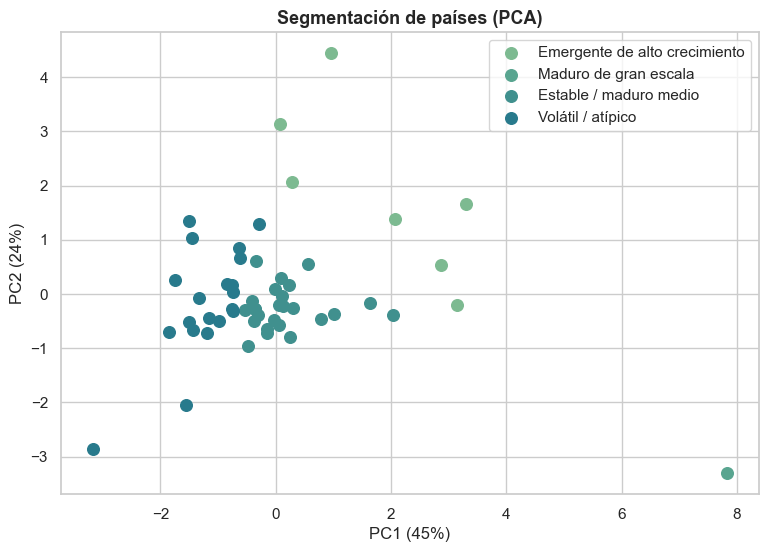

In [4]:
pca_full = pca_2d(feats, CONSUMPTION_FEATURES)
ev = pca_full.attrs['explained_variance']  # capturar antes del merge (merge descarta .attrs)
pca = pca_full.merge(cl[['Country','cluster']], on='Country')
fig, ax = plt.subplots(figsize=(9,6))
for c in sorted(pca['cluster'].unique()):
    sub = pca[pca.cluster==c]
    ax.scatter(sub['pc1'], sub['pc2'], s=70, label=names.get(c, f'Cluster {c}'))
ax.set_xlabel(f'PC1 ({ev[0]:.0%})'); ax.set_ylabel(f'PC2 ({ev[1]:.0%})')
ax.legend(); ax.set_title('Segmentación de países (PCA)'); plt.show()

## 4. Vista (ii): clustering por preferencia de tipo de café

In [5]:
cl_pref = cluster_view(feats, PREFERENCE_FEATURES, k=4, label_col='cluster_pref')
cl_pref.groupby('cluster_pref')[['arabica_dominant','log_level_mean','cagr_recent']].mean().round(3)

,arabica_dominant,log_level_mean,cagr_recent
cluster_pref,,,
0,0.0,15.041,0.020
1,1.0,16.749,0.010
2,1.0,11.695,0.004
3,0.0,11.188,-0.185


## 5. Detección de anomalías multivariante (IsolationForest)

In [6]:
anom = detect_anomalies(feats)
anom[anom['anomaly']][['Country','Coffee type','cagr_recent','volatility']]

,Country,Coffee type,cagr_recent,volatility
0,Brazil,Arabica/Robusta,0.018085,0.022597
1,Tanzania,Arabica/Robusta,0.072908,0.842460
2,Togo,Robusta,-0.184556,0.260042
3,Viet Nam,Robusta/Arabica,0.081728,0.104199
4,Côte d'Ivoire,Robusta,0.000000,0.990369
5,Gabon,Robusta,0.071773,0.554537


## 6. Clasificador de preferencia de tipo (RandomForest, CV)

¿El patrón de consumo (nivel, crecimiento, volatilidad) contiene información sobre si un país es Arabica-dominante? Se reporta accuracy con validación cruzada sobre el baseline de la clase mayoritaria — honesto sobre el n pequeño.

In [7]:
clf = classify_coffee_preference(feats)
print(f"CV accuracy: {clf['cv_accuracy_mean']:.2f} ± {clf['cv_accuracy_std']:.2f} "
      f"(baseline {clf['majority_baseline']:.2f})")
clf['feature_importances'].round(3)

CV accuracy: 0.52 ± 0.16 (baseline 0.55)


volatility         0.265
cagr_full          0.221
log_level_mean     0.192
share_of_global    0.189
cagr_recent        0.133
dtype: float64